<a href="https://colab.research.google.com/github/7500nidhi/Assignment12_c12/blob/main/Assignment12_c12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Required Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [2]:
# Load the Dataset

# Load Fashion MNIST dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Explore the Dataset

print("Training images shape:", X_train.shape)
print("Training labels shape:", y_train.shape)

print("Testing images shape:", X_test.shape)
print("Testing labels shape:", y_test.shape)

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Testing images shape: (10000, 28, 28)
Testing labels shape: (10000,)


In [4]:
# Create Class Names according to given in documentation

class_names = [
    "T-shirt/Top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]


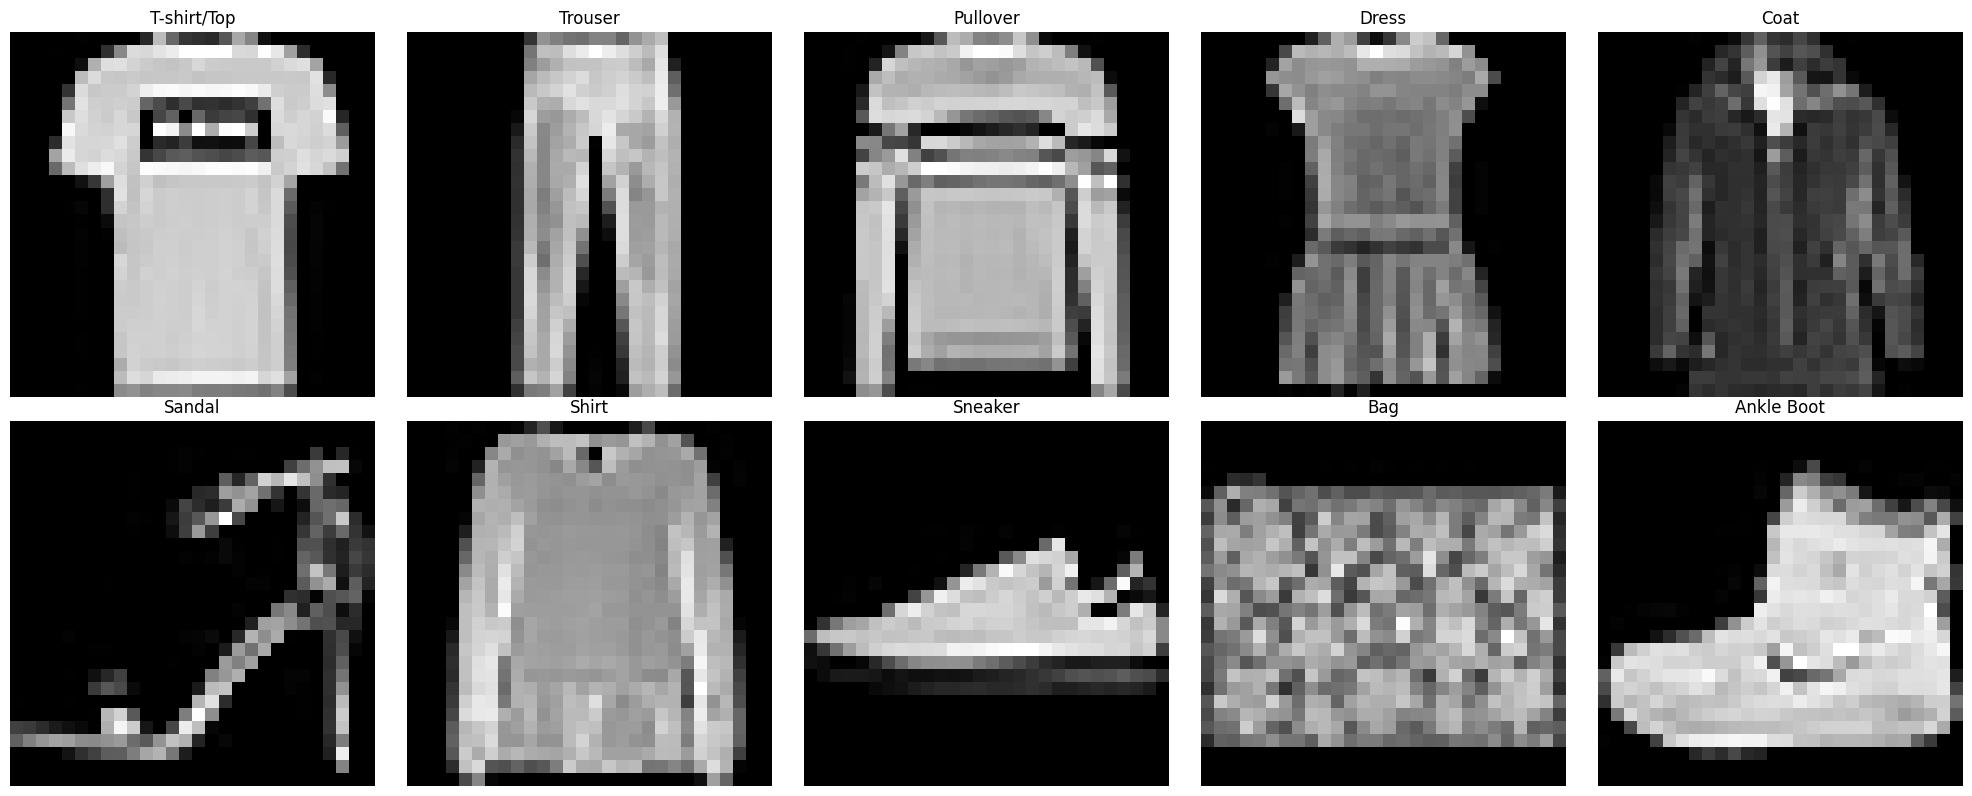

In [5]:
# Visualize Sample Images

plt.figure(figsize=(20,8))

for label in range(10):

    index = np.where(y_train == label)[0][0]

    plt.subplot(2,5,label+1)
    plt.imshow(X_train[index], cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Image Preprocessing

# Normalize the Images

X_train = X_train / 255.0
X_test = X_test / 255.0

In [7]:
# One-Hot Encode the Labels

# Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [8]:
# Check the new shape:

print(y_train.shape)
print(y_test.shape)

(60000, 10)
(10000, 10)


In [9]:
# Initialize the neural network
model = Sequential()

In [10]:
# Add the Input Layer
model.add(Flatten(input_shape=(28, 28)))

# Add a Hidden Layer
model.add(Dense(units=128, activation='relu'))

# Add the Output Layer
model.add(Dense(units=10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# View the Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

The neural network consists of a Flatten layer, one hidden Dense layer with 128 neurons, and an output Dense layer with 10 neurons. The Flatten layer converts each 28 × 28 image into a 784-element vector. The hidden layer uses the ReLU activation function to learn image features, while the output layer uses the Softmax activation function to classify the image into one of the 10 clothing categories. The model has 101,770 trainable parameters, which are updated during training to improve its performance.

In [12]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

#

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8206 - loss: 0.5134 - val_accuracy: 0.8493 - val_loss: 0.4290
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8597 - loss: 0.3849 - val_accuracy: 0.8552 - val_loss: 0.3986
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8736 - loss: 0.3478 - val_accuracy: 0.8666 - val_loss: 0.3662
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8820 - loss: 0.3231 - val_accuracy: 0.8773 - val_loss: 0.3399
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8882 - loss: 0.3015 - val_accuracy: 0.8794 - val_loss: 0.3388
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8950 - loss: 0.2855 - val_accuracy: 0.8830 - val_loss: 0.3309
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8977 - loss: 0.2753 - val_accuracy: 0.8784 - val_loss: 0.3337
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.9021 - loss: 0.2632 -

**Training Results:** The model was trained for 15 epochs using the Fashion MNIST dataset. During training, the accuracy increased from around 86% to 92%, while the loss gradually decreased, showing that the model learned the image patterns effectively. The validation accuracy remained around 88–89%, indicating that the model performs well on unseen data and does not show significant overfitting.

In [13]:
# Evaluate the Model on the Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8773 - loss: 0.3710
Test Loss: 0.37096890807151794
Test Accuracy: 0.8773000240325928


**Model Evaluation:** The trained model was evaluated on the test dataset and achieved a test accuracy of 87.73% with a test loss of 0.3710. The results indicate that the neural network correctly classified most of the clothing images and performed well on unseen data, demonstrating good overall classification performance.

In [14]:
# Make Predictions

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


**Prediction:** The trained model was used to predict the clothing categories for the test images. The predicted probabilities were converted into the most likely class labels using argmax(). The actual test labels were also converted back to class labels so that the predicted and true values could be compared during model evaluation.

In [15]:
# Accuracy Score

accuracy = accuracy_score(y_true, y_pred_classes)

print("Accuracy:", accuracy)

Accuracy: 0.8773


**Prediction:** The trained model was used to predict the clothing categories for the test images. The predicted probabilities were converted into the most likely class labels using argmax(). The actual test labels were also converted back to class labels so that the predicted and true values could be compared during model evaluation.

In [16]:
# Classification Report
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))


              precision    recall  f1-score   support

 T-shirt/Top       0.81      0.88      0.84      1000
     Trouser       0.94      0.99      0.96      1000
    Pullover       0.74      0.83      0.78      1000
       Dress       0.91      0.86      0.89      1000
        Coat       0.75      0.83      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.81      0.54      0.64      1000
     Sneaker       0.95      0.94      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.93      0.97      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



**Classification Report:** The classification report shows the model's precision, recall, and F1-score for each clothing category. The model achieved an overall accuracy of 88%, with strong performance on classes such as Trouser, Sandal, Bag, and Ankle Boot. Lower performance was observed for the Shirt class, indicating that it was more difficult for the model to distinguish from similar clothing items. Overall, the model performed well across most categories.

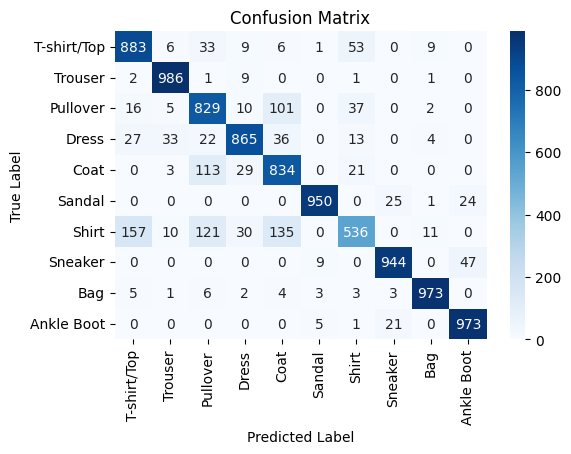

In [18]:
# Confusion Matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

**Confusion Matrix:** The confusion matrix shows how well the model classified each clothing category. Most predictions are on the diagonal, indicating that the model correctly classified most images. Some errors occurred between similar clothing items, such as Shirt, Pullover, and Coat, which are more difficult to distinguish. Overall, the confusion matrix shows that the model achieved good classification performance across most classes.

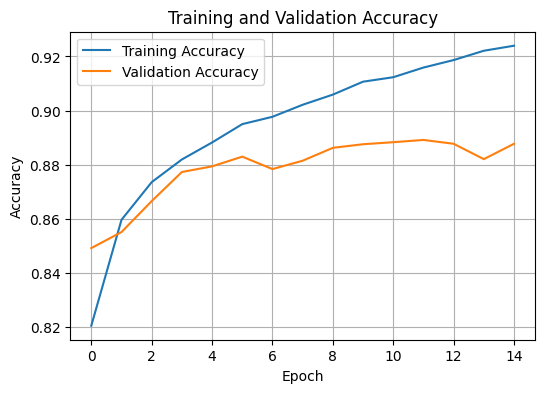

In [20]:
# Plot Training and Validation Accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

**Training and Validation Accuracy:** The graph shows that both the training and validation accuracy improved as the number of epochs increased. The training accuracy reached about 92%, while the validation accuracy remained around 89%. This indicates that the model learned effectively from the training data and performed well on unseen data with only a small difference between the two accuracies.

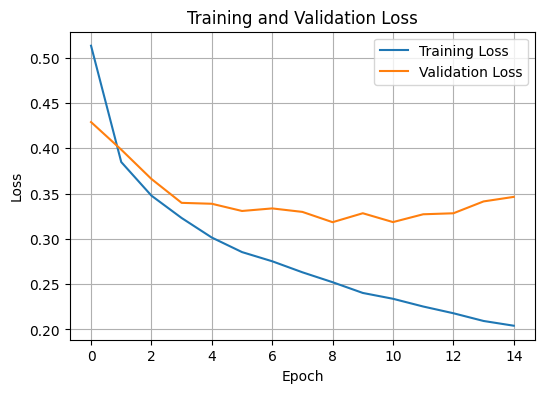

In [22]:
# Plot Training and Validation Loss
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

**Training and Validation Loss:** The graph shows that the training loss decreased steadily during the training process, indicating that the model learned the data effectively. The validation loss also decreased initially and then remained fairly stable with a slight increase in the later epochs. This suggests that the model achieved good performance on the validation data with only a small amount of overfitting.

In [23]:
# model improvement

improved_model = Sequential()

improved_model.add(Flatten(input_shape=(28,28)))

improved_model.add(Dense(256, activation='relu'))
improved_model.add(Dense(128, activation='relu'))

improved_model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
# compile
improved_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
# Train
history2 = improved_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8221 - loss: 0.4947 - val_accuracy: 0.8526 - val_loss: 0.3995
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8640 - loss: 0.3697 - val_accuracy: 0.8680 - val_loss: 0.3646
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8770 - loss: 0.3296 - val_accuracy: 0.8709 - val_loss: 0.3477
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8861 - loss: 0.3063 - val_accuracy: 0.8773 - val_loss: 0.3326
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8917 - loss: 0.2874 - val_accuracy: 0.8812 - val_loss: 0.3273
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8972 - loss: 0.2729 - val_accuracy: 0.8829 - val_loss: 0.3250
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9020 - loss: 0.2608 - val_accuracy: 0.8867 - val_loss: 0.3163
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9060 - loss: 0.2497 -

**Model Improvement:** To improve the model's performance, an additional hidden layer with more neurons was added while keeping the Adam optimizer. The improved model was trained for 10 epochs. During training, the training accuracy increased from 82.21% to 91.28%, while the validation accuracy reached 88.84%. The results show that the improved model learned the image features effectively and achieved good performance on the validation data.

In [26]:
# Evaluate
test_loss2, test_accuracy2 = improved_model.evaluate(X_test, y_test)

print("Improved Model Accuracy:", test_accuracy2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8786 - loss: 0.3597
Improved Model Accuracy: 0.878600001335144


**Improved Model Evaluation: **The improved model was evaluated on the test dataset and achieved a test accuracy of 87.86% with a test loss of 0.3597. Compared with the original model, the accuracy increased slightly, showing that adding an extra hidden layer had a small positive effect on the model's performance.

**Data Augmentation:** Data augmentation was not implemented because the objective of this assignment was to build and evaluate a basic feedforward neural network. Although augmentation can improve model generalization by generating transformed training images, its impact is generally greater for Convolutional Neural Networks (CNNs) than for simple feedforward neural networks.

**Application Demonstration**
**Practical Deployment Scenario**

The trained neural network can be used in an online fashion store to automatically identify clothing items such as T-shirts, dresses, shoes, and bags. This helps organize products, saves time, and improves the shopping experience.

**Operational Challenges**
**Model Scalability:** The system should handle many product images as the business grows.
**Real-Time Processing:** The model should classify images quickly when they are uploaded.
**Integration:** The model should work with the online store and inventory system.
**Model Maintenance: **The model should be updated regularly with new clothing images to maintain good accuracy.

git repo link: https://github.com/7500nidhi/Assignment12_c12.git